In [1]:
import pandas as pd
import numpy as np


In [2]:
df  = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [4]:
x = df.drop("Outcome" , axis = 1).values
y = df.Outcome.values

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scl = StandardScaler()

x = scl.fit_transform(x)

In [7]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size = 0.2 , random_state = 1)

In [8]:
import tensorflow
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense , Dropout

In [10]:
model  = Sequential()

model.add(Dense(32 , activation = "relu" , input_dim = 8))
model.add(Dense(1 , activation = "sigmoid"))

In [11]:
model.compile(optimizer = "adam" , loss = "binary_crossentropy" , metrics = ["accuracy"])

In [12]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 32)                288       
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 321 (1.25 KB)
Trainable params: 321 (1.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
history = model.fit(x_train , y_train , validation_data = (x_test , y_test) , epochs =10 , batch_size = 32)

Epoch 1/10


20/20 [==============================] - 3s 21ms/step - loss: 0.6502 - accuracy: 0.6645 - val_loss: 0.6164 - val_accuracy: 0.6883
Epoch 2/10
20/20 [==============================] - 0s 4ms/step - loss: 0.5965 - accuracy: 0.6971 - val_loss: 0.5756 - val_accuracy: 0.7273
Epoch 3/10
20/20 [==============================] - 0s 5ms/step - loss: 0.5610 - accuracy: 0.7362 - val_loss: 0.5468 - val_accuracy: 0.7597
Epoch 4/10
20/20 [==============================] - 0s 4ms/step - loss: 0.5357 - accuracy: 0.7443 - val_loss: 0.5258 - val_accuracy: 0.7468
Epoch 5/10
20/20 [==============================] - 0s 4ms/step - loss: 0.5169 - accuracy: 0.7606 - val_loss: 0.5106 - val_accuracy: 0.7597
Epoch 6/10
20/20 [==============================] - 0s 4ms/step - loss: 0.5030 - accuracy: 0.7687 - val_loss: 0.5000 - val_accuracy: 0.7792
Epoch 7/10
20/20 [==============================] - 0s 4ms/step - loss: 0.4937 - accuracy: 0.7671 - val_loss: 0.4916 - val_accuracy: 0.7857
Epoch 8/10
20/20 

## how to select apropiate optimizer
## no of nodes in a layer
## how to select no of layers


In [14]:
import keras_tuner as kt

In [15]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(32 , activation = "relu" , input_dim = 8))
    model.add(Dense(1 , activation = "sigmoid"))

    optimizer = hp.Choice('optimizer' , values= ["adam" , "sgd" , "rmsprop" , "adadelta" , "nadam"])
    model.compile(optimizer = optimizer , loss = "binary_crossentropy" , metrics = ['accuracy'])
    return model

In [16]:
tuner = kt.RandomSearch(build_model,
                       objective = "val_accuracy",
                       max_trials = 5)

Reloading Tuner from .\untitled_project\tuner0.json


In [17]:
tuner.search(x_train , y_train , epochs = 5 , validation_data = (x_test , y_test), verbose = 1)

In [18]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'nadam'}

In [19]:
model1  = tuner.get_best_models(num_models = 1)[0]

In [20]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 321 (1.25 KB)
Trainable params: 321 (1.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
model1.fit(x_train ,y_train ,batch_size  = 32 , epochs = 100 , initial_epoch = 6 , validation_data = (x_test , y_test))

Epoch 7/100
20/20 [==============================] - 3s 21ms/step - loss: 0.5650 - accuracy: 0.7671 - val_loss: 0.5372 - val_accuracy: 0.7857
Epoch 8/100
20/20 [==============================] - 0s 6ms/step - loss: 0.5473 - accuracy: 0.7834 - val_loss: 0.5180 - val_accuracy: 0.7922
Epoch 9/100
20/20 [==============================] - 0s 6ms/step - loss: 0.5320 - accuracy: 0.7866 - val_loss: 0.5068 - val_accuracy: 0.7662
Epoch 10/100
20/20 [==============================] - 0s 5ms/step - loss: 0.5195 - accuracy: 0.7785 - val_loss: 0.4936 - val_accuracy: 0.7792
Epoch 11/100
20/20 [==============================] - 0s 5ms/step - loss: 0.5081 - accuracy: 0.7769 - val_loss: 0.4833 - val_accuracy: 0.7857
Epoch 12/100
20/20 [==============================] - 0s 6ms/step - loss: 0.4987 - accuracy: 0.7769 - val_loss: 0.4767 - val_accuracy: 0.7727
Epoch 13/100
20/20 [==============================] - 0s 5ms/step - loss: 0.4908 - accuracy: 0.7736 - val_loss: 0.4700 - val_accuracy: 0.7727
Epoch 14

In [24]:
def build_model1(hp):
    model = Sequential()
    units = hp.Int(name = "units" , min_value = 8 ,max_value = 128)
    model.add(Dense(units = units , activation = "relu", input_dim = 8))
    model.add(Dense(1 , activation = "sigmoid"))

    model.compile(optimizer = "rmsprop" , loss = "binary_crossentropy" , metrics = ['accuracy'])
    return model

In [25]:
tuner1 = kt.RandomSearch(build_model1, 
                       objective = "val_accuracy" , 
                       max_trials = 5,
                        directory = "new_dir",
                        project_name = "ss")

Reloading Tuner from new_dir\ss\tuner0.json


In [26]:
tuner1.search(x_train , y_train , epochs = 5 , validation_data = (x_test , y_test))

In [27]:
tuner1.get_best_hyperparameters()[0].values

{'units': 117}

In [28]:
model3 = tuner1.get_best_models(num_models = 1)[0]

In [30]:
model3.fit(x_train , y_train , validation_data = (x_test , y_test) , batch_size = 32 , epochs = 100 , initial_epoch = 6)

Epoch 7/100
20/20 [==============================] - 1s 15ms/step - loss: 0.4668 - accuracy: 0.7834 - val_loss: 0.4643 - val_accuracy: 0.7922
Epoch 8/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4610 - accuracy: 0.7834 - val_loss: 0.4621 - val_accuracy: 0.7922
Epoch 9/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4566 - accuracy: 0.7850 - val_loss: 0.4634 - val_accuracy: 0.7922
Epoch 10/100
20/20 [==============================] - 0s 3ms/step - loss: 0.4535 - accuracy: 0.7834 - val_loss: 0.4614 - val_accuracy: 0.7987
Epoch 11/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4515 - accuracy: 0.7785 - val_loss: 0.4613 - val_accuracy: 0.8052
Epoch 12/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4496 - accuracy: 0.7785 - val_loss: 0.4613 - val_accuracy: 0.7987
Epoch 13/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4480 - accuracy: 0.7818 - val_loss: 0.4600 - val_accuracy: 0.8182
Epoch 14

In [31]:
# number of layers

In [32]:
def build_model3(hp):
    model = Sequential()
    model.add(Dense(72 , activation = "relu" , input_dim = 8))

    for i in range(hp.Int("num_layers" , min_value = 1 , max_value=10)):
        model.add(Dense(72 , activation = "relu"))

    model.add(Dense(1 , activation = "sigmoid"))

    model.compile(loss= "binary_crossentropy" , optimizer = "rmsprop" , metrics = ['accuracy'])
    return model

In [33]:
tuner = kt.RandomSearch(build_model3,
                       objective = "val_accuracy" , 
                       max_trials =3,
                       directory = "new_dir" , 
                       project_name = "num_layers")

Reloading Tuner from new_dir\num_layers\tuner0.json


In [34]:
tuner.search(x_train , y_train , validation_data = (x_test , y_test) , epochs = 6)

In [35]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 5}

In [36]:
model4 = tuner.get_best_models(num_models = 1)[0]

In [37]:
model4.fit(x_train , y_train , validation_data=(x_test , y_test) , epochs = 100 , initial_epoch = 6 , batch_size = 32)

Epoch 7/100
20/20 [==============================] - 1s 17ms/step - loss: 0.4319 - accuracy: 0.7883 - val_loss: 0.4637 - val_accuracy: 0.7922
Epoch 8/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4277 - accuracy: 0.7899 - val_loss: 0.4465 - val_accuracy: 0.8052
Epoch 9/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4156 - accuracy: 0.7932 - val_loss: 0.4659 - val_accuracy: 0.7662
Epoch 10/100
20/20 [==============================] - 0s 4ms/step - loss: 0.4068 - accuracy: 0.7980 - val_loss: 0.4924 - val_accuracy: 0.7597
Epoch 11/100
20/20 [==============================] - 0s 4ms/step - loss: 0.3966 - accuracy: 0.8143 - val_loss: 0.4476 - val_accuracy: 0.7987
Epoch 12/100
20/20 [==============================] - 0s 5ms/step - loss: 0.3874 - accuracy: 0.8143 - val_loss: 0.4685 - val_accuracy: 0.7727
Epoch 13/100
20/20 [==============================] - 0s 4ms/step - loss: 0.3788 - accuracy: 0.8306 - val_loss: 0.4863 - val_accuracy: 0.7727
Epoch 14

In [38]:
def build_model5(hp):
    model = Sequential()

    counter = 0

    for i in range(hp.Int("num_layers" , min_value = 1 , max_value = 10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int("units" +str(i) , min_value = 8 , max_value = 128 , step = 8),
                activation = hp.Choice("activation"+str(i) , values = ["relu" , "sigmoid" , "elu" , "tanh" , "linear"]),
                input_dim = 8))
        else:
            model.add(
                Dense(
                    hp.Int("units" +str(i) , min_value = 8 , max_value = 128 , step = 8),
                activation = hp.Choice("activation"+str(i) , values = ["relu" , "sigmoid" , "elu" , "tanh" , "linear"])))
        counter+=1

    model.add(Dense(1 , activation = "sigmoid"))
    model.compile(loss = "binary_crossentropy" , optimizer = hp.Choice("optimizer" , values = ["adam" , "nadam" , "rmsprop" , "sgd" , "adadelta"]) , metrics = ['accuracy'])
    return model

In [39]:
tuner5 = kt.RandomSearch(build_model5 , 
                        objective = "val_accuracy" ,
                        max_trials = 5, 
                        directory = "new_dir" ,
                        project_name = "combine")

Reloading Tuner from new_dir\combine\tuner0.json


In [40]:
tuner5.search(x_train , y_train , epochs = 6 , validation_data = (x_test , y_test))

In [41]:
tuner5.get_best_hyperparameters()[0].values

{'num_layers': 9,
 'units0': 80,
 'activation0': 'linear',
 'optimizer': 'adam',
 'units1': 24,
 'activation1': 'elu',
 'units2': 48,
 'activation2': 'sigmoid',
 'units3': 80,
 'activation3': 'linear',
 'units4': 48,
 'activation4': 'tanh',
 'units5': 40,
 'activation5': 'elu',
 'units6': 48,
 'activation6': 'relu',
 'units7': 32,
 'activation7': 'relu',
 'units8': 24,
 'activation8': 'tanh'}

In [42]:
model7 = tuner.get_best_models(num_models = 1)[0]

In [43]:
history = model7.fit(x_train ,y_train , validation_data = (x_test , y_test) , epochs = 100 , initial_epoch = 6 , batch_size = 32)

Epoch 7/100
20/20 [==============================] - 2s 25ms/step - loss: 0.4322 - accuracy: 0.7866 - val_loss: 0.5481 - val_accuracy: 0.7338
Epoch 8/100
20/20 [==============================] - 0s 7ms/step - loss: 0.4279 - accuracy: 0.7948 - val_loss: 0.4417 - val_accuracy: 0.8182
Epoch 9/100
20/20 [==============================] - 0s 8ms/step - loss: 0.4129 - accuracy: 0.8078 - val_loss: 0.4515 - val_accuracy: 0.7987
Epoch 10/100
20/20 [==============================] - 0s 7ms/step - loss: 0.4049 - accuracy: 0.8160 - val_loss: 0.4725 - val_accuracy: 0.7987
Epoch 11/100
20/20 [==============================] - 0s 8ms/step - loss: 0.4076 - accuracy: 0.8013 - val_loss: 0.4477 - val_accuracy: 0.7922
Epoch 12/100
20/20 [==============================] - 0s 8ms/step - loss: 0.3851 - accuracy: 0.8241 - val_loss: 0.4475 - val_accuracy: 0.7792
Epoch 13/100
20/20 [==============================] - 0s 9ms/step - loss: 0.3791 - accuracy: 0.8290 - val_loss: 0.4640 - val_accuracy: 0.7922
Epoch 14

In [44]:
import matplotlib.pyplot as plt

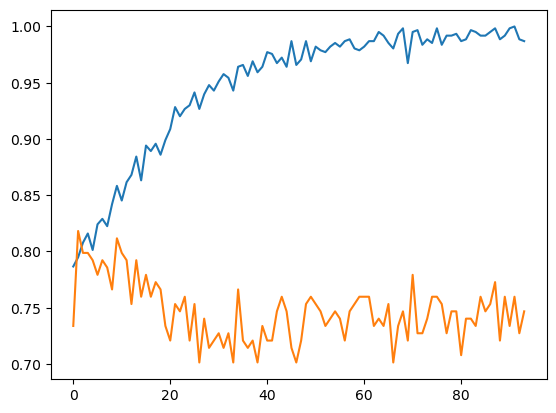

In [45]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])


In [46]:
def build_model7(hp):
    model = Sequential()

    counter = 0

    for i in range(hp.Int("num_layers" , min_value = 1 , max_value = 10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int("units" +str(i) , min_value = 8 , max_value = 128 , step = 8),
                activation = hp.Choice("activation"+str(i) , values = ["relu" , "sigmoid" , "elu" , "tanh" , "linear"]),
                input_dim = 8))
            model.add(Dropout(hp.Choice("dropout" +str(i) , values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        else:
            model.add(
                Dense(
                    hp.Int("units" +str(i) , min_value = 8 , max_value = 128 , step = 8),
                activation = hp.Choice("activation"+str(i) , values = ["relu" , "sigmoid" , "elu" , "tanh" , "linear"])))
            model.add(Dropout(hp.Choice("dropout" +str(i) , values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
            
        counter+=1

    model.add(Dense(1 , activation = "sigmoid"))
    model.compile(loss = "binary_crossentropy" , optimizer = hp.Choice("optimizer" , values = ["adam" , "nadam" , "rmsprop" , "sgd" , "adadelta"]) , metrics = ['accuracy'])
    return model

In [47]:
tuner7 = kt.RandomSearch(build_model7 , 
                        objective = "val_accuracy" ,
                        max_trials = 10, 
                        directory = "new_dir" ,
                        project_name = "combine4")

Reloading Tuner from new_dir\combine4\tuner0.json


In [48]:
tuner7.search(x_train , y_train , epochs = 6 , validation_data = (x_test , y_test))


In [49]:
tuner7.get_best_hyperparameters()[0].values

{'num_layers': 3,
 'units0': 128,
 'activation0': 'elu',
 'dropout0': 0.6,
 'optimizer': 'adam',
 'units1': 8,
 'activation1': 'relu',
 'dropout1': 0.1,
 'units2': 8,
 'activation2': 'relu',
 'dropout2': 0.1}

In [50]:
model7 = tuner7.get_best_models(num_models = 1)[0]

In [51]:
history = model7.fit(x_train ,y_train , validation_data = (x_test , y_test) , epochs = 200 , initial_epoch = 6 , batch_size = 32)

Epoch 7/200
20/20 [==============================] - 2s 15ms/step - loss: 0.5718 - accuracy: 0.7068 - val_loss: 0.5136 - val_accuracy: 0.7922
Epoch 8/200
20/20 [==============================] - 0s 5ms/step - loss: 0.5340 - accuracy: 0.7182 - val_loss: 0.4813 - val_accuracy: 0.7857
Epoch 9/200
20/20 [==============================] - 0s 4ms/step - loss: 0.5445 - accuracy: 0.7410 - val_loss: 0.4697 - val_accuracy: 0.7792
Epoch 10/200
20/20 [==============================] - 0s 4ms/step - loss: 0.5059 - accuracy: 0.7378 - val_loss: 0.4702 - val_accuracy: 0.7922
Epoch 11/200
20/20 [==============================] - 0s 4ms/step - loss: 0.5129 - accuracy: 0.7329 - val_loss: 0.4688 - val_accuracy: 0.7792
Epoch 12/200
20/20 [==============================] - 0s 4ms/step - loss: 0.5035 - accuracy: 0.7313 - val_loss: 0.4689 - val_accuracy: 0.7727
Epoch 13/200
20/20 [==============================] - 0s 4ms/step - loss: 0.5216 - accuracy: 0.7394 - val_loss: 0.4699 - val_accuracy: 0.7597
Epoch 14

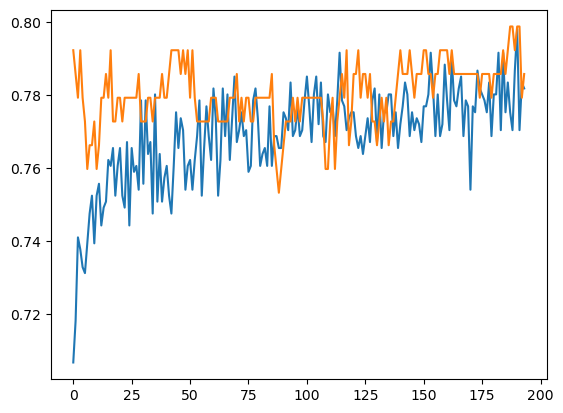

In [52]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
